# Feature Analysis — CSIC 2010

**Objetivo:** Entender por qué los modelos tienen techo de Precision ~0.65 e identificar features nuevas que permitan superarlo.

**Contexto:** Todos los modelos entrenados (LR, RF, XGBoost, LightGBM) cumplen Recall ≥ 0.95 pero no alcanzan Precision ≥ 0.85. El ROC-AUC se estanca en ~0.94 con las 15 features actuales.

**Plan:**
1. Feature importance del Random Forest — ver qué features aportan y cuáles son ruido
2. Análisis de falsos positivos — qué tráfico normal confunde al modelo
3. Features nuevas candidatas
4. Medir impacto de las features nuevas en ROC-AUC y Precision

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score

pd.set_option('display.max_columns', None)

PROCESSED_PATH = '../../data/processed/csic2010/features.parquet'
RAW_PATH       = '../../data/raw/csic2010/csic_database.csv'
RANDOM_STATE   = 42
MIN_RECALL     = 0.95
MIN_PRECISION  = 0.85

## 1. Cargar datos y entrenar RF base

In [2]:
df = pd.read_parquet(PROCESSED_PATH)
feature_names = df.drop(columns=['label']).columns.tolist()

X = df.drop(columns=['label']).values.astype('float32')
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

continuous_idx = [feature_names.index(c) for c in ['url_length', 'content_length']]
scaler = StandardScaler()
X_train[:, continuous_idx] = scaler.fit_transform(X_train[:, continuous_idx])
X_val[:, continuous_idx]   = scaler.transform(X_val[:, continuous_idx])
X_test[:, continuous_idx]  = scaler.transform(X_test[:, continuous_idx])

rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
print('Modelo entrenado ✅')
print(f'Train: {len(y_train)} | Val: {len(y_val)} | Test: {len(y_test)}')

Modelo entrenado ✅
Train: 42745 | Val: 9160 | Test: 9160


## 2. Feature importance

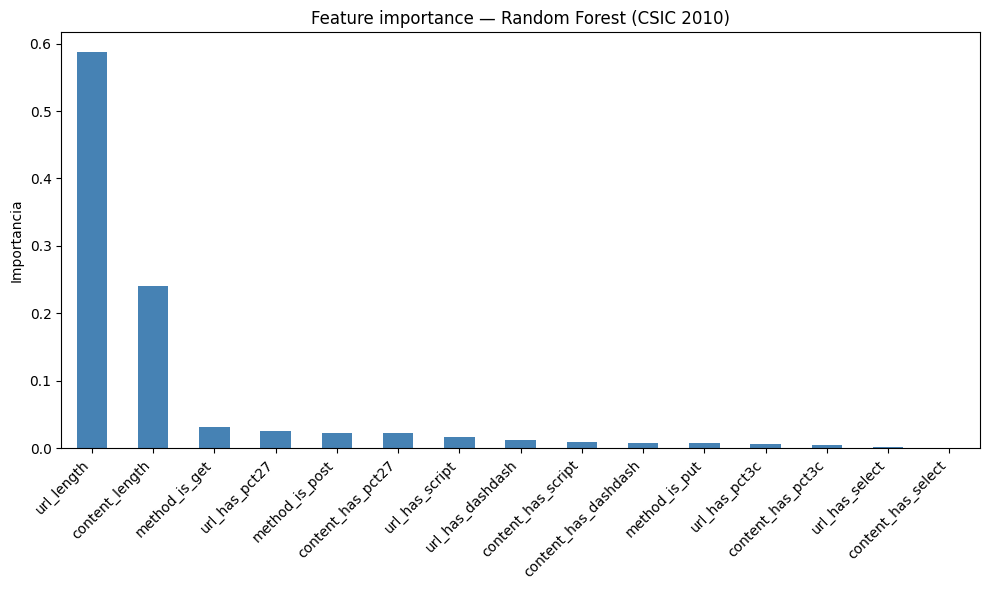


Ranking completo:
url_length              0.5873
content_length          0.2409
method_is_get           0.0322
url_has_pct27           0.0254
method_is_post          0.0233
content_has_pct27       0.0231
url_has_script          0.0166
url_has_dashdash        0.0126
content_has_script      0.0088
content_has_dashdash    0.0080
method_is_put           0.0078
url_has_pct3c           0.0071
content_has_pct3c       0.0051
url_has_select          0.0013
content_has_select      0.0004


In [3]:
importances = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Feature importance — Random Forest (CSIC 2010)')
ax.set_ylabel('Importancia')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nRanking completo:')
print(importances.round(4).to_string())

## 3. Análisis de falsos positivos

¿Qué tráfico normal está confundiendo al modelo?

In [4]:
# Obtener predicciones en test con threshold 0.15 (el óptimo del training)
THRESHOLD = 0.15
test_proba = rf.predict_proba(X_test)[:, 1]
test_pred  = (test_proba >= THRESHOLD).astype(int)

# Falsos positivos: label=0 pero predicho como 1
fp_mask = (y_test == 0) & (test_pred == 1)
fn_mask = (y_test == 1) & (test_pred == 0)

print(f'Falsos Positivos (FP): {fp_mask.sum()} — tráfico normal clasificado como ataque')
print(f'Falsos Negativos (FN): {fn_mask.sum()} — ataques no detectados')
print()

# Ver distribución de features en FP vs tráfico normal correcto
tn_mask = (y_test == 0) & (test_pred == 0)

X_test_df = pd.DataFrame(X_test, columns=feature_names)
print('Features en FP vs TN (tráfico normal bien clasificado):')
comparison = pd.DataFrame({
    'FP (confundido)': X_test_df[fp_mask].mean(),
    'TN (correcto)':   X_test_df[tn_mask].mean(),
}).round(3)
print(comparison)

Falsos Positivos (FP): 1886 — tráfico normal clasificado como ataque
Falsos Negativos (FN): 185 — ataques no detectados

Features en FP vs TN (tráfico normal bien clasificado):
                      FP (confundido)  TN (correcto)
method_is_get                   0.698          0.823
method_is_post                  0.302          0.177
method_is_put                   0.000          0.000
url_length                      0.233         -0.384
url_has_pct27                   0.002          0.000
url_has_pct3c                   0.000          0.000
url_has_dashdash                0.000          0.000
url_has_script                  0.000          0.000
url_has_select                  0.000          0.000
content_length                  0.243         -0.357
content_has_pct27               0.004          0.000
content_has_pct3c               0.000          0.000
content_has_dashdash            0.000          0.000
content_has_script              0.000          0.000
content_has_select          

## 4. Features nuevas candidatas

A partir del análisis de FP, construir features que ayuden a distinguir mejor.

In [5]:
# Cargar datos crudos para construir features nuevas
raw = pd.read_csv(RAW_PATH)
raw = raw.rename(columns={'classification': 'label'})

# Feature: número de parámetros en la URL (count de '=')
raw['url_param_count'] = raw['URL'].str.count('=').fillna(0).astype('int16')

# Feature: ratio de caracteres encoded sobre longitud total de URL
raw['url_pct_density'] = (
    raw['URL'].str.count('%').fillna(0) / raw['URL'].str.len().clip(lower=1)
).astype('float32')

# Feature: presencia de path traversal (../ o %2F)
raw['url_has_traversal'] = raw['URL'].str.contains(r'\.\./', regex=True, case=False).astype('int8')

# Feature: features cruzadas method x indicador
raw['method_is_post'] = (raw['Method'].str.upper() == 'POST').astype('int8')
raw['method_is_put']  = (raw['Method'].str.upper() == 'PUT').astype('int8')
raw['url_has_pct27']  = raw['URL'].str.contains('%27', case=False, regex=False).astype('int8')
raw['post_has_pct27'] = (raw['method_is_post'] & raw['URL'].str.contains('%27', case=False, regex=False)).astype('int8')

new_features = ['url_param_count', 'url_pct_density', 'url_has_traversal', 'post_has_pct27']

print('Correlación de features nuevas con label:')
corr = raw[new_features + ['label']].corr()['label'].drop('label').sort_values(ascending=False)
print(corr.round(4).to_string())

Correlación de features nuevas con label:
url_pct_density      0.2674
url_param_count      0.1461
url_has_traversal       NaN
post_has_pct27          NaN


## 5. Medir impacto de features nuevas

Comparar ROC-AUC y Precision del RF con y sin las features nuevas.

In [6]:
from sklearn.metrics import precision_recall_curve

def find_best_threshold(y_true, y_proba, min_recall=MIN_RECALL):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    mask = recalls[:-1] >= min_recall
    if not mask.any():
        return float(thresholds[np.argmax(recalls[:-1])])
    return float(thresholds[np.where(mask, precisions[:-1], 0).argmax()])

# Dataset extendido con features nuevas
df_ext = df.copy()
df_ext['url_param_count']  = raw['url_param_count'].values
df_ext['url_pct_density']  = raw['url_pct_density'].values
df_ext['url_has_traversal'] = raw['url_has_traversal'].values
df_ext['post_has_pct27']   = raw['post_has_pct27'].values

feature_names_ext = df_ext.drop(columns=['label']).columns.tolist()
X_ext = df_ext.drop(columns=['label']).values.astype('float32')

X_tr2, X_tmp2, y_tr2, y_tmp2 = train_test_split(X_ext, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_v2, X_te2, y_v2, y_te2     = train_test_split(X_tmp2, y_tmp2, test_size=0.50, stratify=y_tmp2, random_state=RANDOM_STATE)

cont_idx2 = [feature_names_ext.index(c) for c in ['url_length', 'content_length', 'url_param_count', 'url_pct_density']]
sc2 = StandardScaler()
X_tr2[:, cont_idx2] = sc2.fit_transform(X_tr2[:, cont_idx2])
X_v2[:, cont_idx2]  = sc2.transform(X_v2[:, cont_idx2])
X_te2[:, cont_idx2] = sc2.transform(X_te2[:, cont_idx2])

rf2 = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf2.fit(X_tr2, y_tr2)

# Comparar
for name, model, Xv, Xt, yv, yt in [
    ('RF base (15 features)',      rf,  X_val, X_test, y_val, y_test),
    ('RF extendido (19 features)', rf2, X_v2,  X_te2,  y_v2,  y_te2),
]:
    v_proba = model.predict_proba(Xv)[:, 1]
    thr     = find_best_threshold(yv, v_proba)
    t_proba = model.predict_proba(Xt)[:, 1]
    t_pred  = (t_proba >= thr).astype(int)
    print(f'\n{name}')
    print(f'  Threshold:  {thr:.4f}')
    print(f'  ROC-AUC:    {roc_auc_score(yt, t_proba):.4f}')
    print(f'  Recall:     {recall_score(yt, t_pred):.4f}  ({"✅" if recall_score(yt, t_pred) >= MIN_RECALL else "❌"})')
    print(f'  Precision:  {precision_score(yt, t_pred):.4f}  ({"✅" if precision_score(yt, t_pred) >= MIN_PRECISION else "❌"})')


RF base (15 features)
  Threshold:  0.1500
  ROC-AUC:    0.9391
  Recall:     0.9508  (✅)
  Precision:  0.6546  (❌)

RF extendido (19 features)
  Threshold:  0.1343
  ROC-AUC:    0.9496
  Recall:     0.9513  (✅)
  Precision:  0.7040  (❌)


## 6. Observaciones

> Completar después de ejecutar

- **Features más importantes:** _ver sección 2_
- **Patrón en FP:** _qué tráfico normal confunde al modelo_
- **Impacto de features nuevas:** _mejora de ROC-AUC y Precision_
- **Decisión:** _qué features agregar al preprocessing_